# DTLZ3 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1000
NGEN = 600
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz3_segura = partial(benchmarks.dtlz3, obj=NOBJ)
toolbox = build_toolbox(func_dtlz3_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

[1.0, 1.0, 1.0, 1.0, 0.500000000373978, 0.4999999998726546, 0.4999999997626018, 0.5000000002293902, 0.499999999861539]
[0.0, 0.0, 4.947776576717884e-17, 2.1107341875767306e-05, 0.5000000001273666, 0.4999999998787554, 0.4999999999564538, 0.5000000002339343, 0.4999999998735933]
[0.9999980034423717, 1.0, 0.0, 0.0, 0.49999829851653355, 0.5000000001309722, 0.5000000020024982, 0.5000000029928248, 0.4999994748471666]
[0.9999999316236311, 0.0, 0.0, 5.0806801174617354e-18, 0.4999999997132591, 0.5000000001581951, 0.4999999997637801, 0.5000000000803924, 0.49999999996943756]
[1.0, 0.9999856758475086, 0.9999999999998098, 0.0, 0.4999999994915544, 0.4999999997636136, 0.5000002556478147, 0.49998655942157005, 0.49999999986965904]
[1.4404871857728784e-12, 0.0, 0.9614672394980301, 0.0, 0.4998721029625529, 0.4743086710208729, 0.4994789755949372, 0.4999281636422185, 0.44992019644658465]
[0.0, 0.0, 0.01759943256076585, 0.9999999955885478, 0.5615102389361846, 0.3854827879012394, 0.5160955686075509, 0.5000513

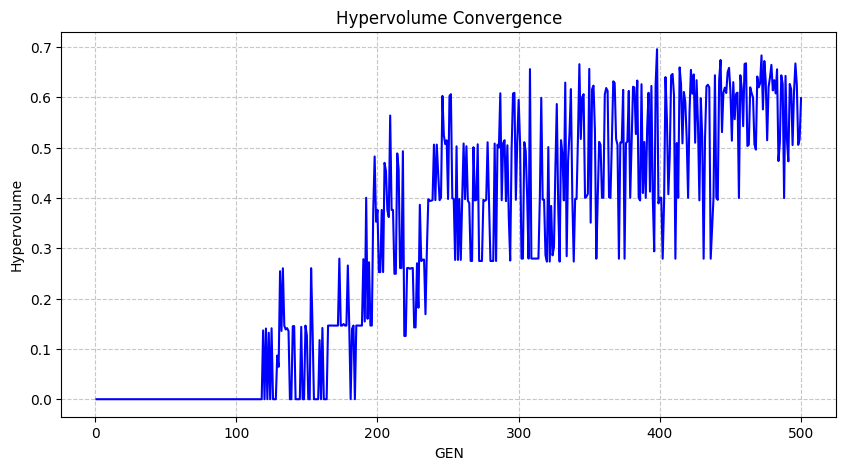

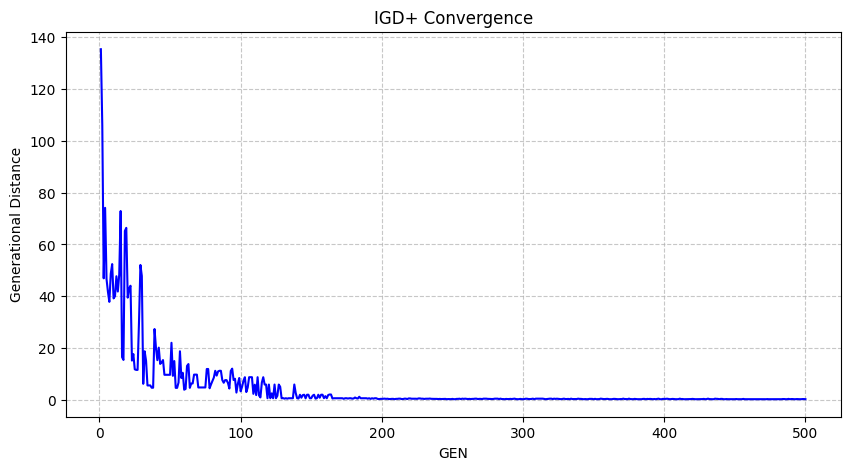

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()